# Levy process (heavy tails)

A Levy (alpha-stable) process generalizes Brownian motion to allow *heavy tails* and jumps: increments are independent but drawn from a stable distribution whose tail weight is tunable. It models series with occasional extreme moves that a Gaussian model badly underestimates.

::: {.callout-note}
## The model

$$y_t = y_{t-1} + \text{scale}\cdot X_t + \text{location}, \qquad X_t \sim S(\alpha, \beta; 1)$$

The stability index `alpha` ∈ (0, 2] sets the tail heaviness: `alpha = 2` recovers Gaussian increments, while smaller values give progressively heavier tails and larger jumps (`alpha = 1` is Cauchy-like, with undefined variance).
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import LevyProcessGenerator

## 1. Gaussian case (alpha=2)

When alpha=2, the Levy process reduces to a standard Brownian motion (Gaussian increments).

In [ ]:
gauss_gen = LevyProcessGenerator(engine="polars", 
    min_length=500,
    max_length=500,
    freq="D",
    alpha=2.0,
    cumulative=True,
    initial_value=100.0,
    seed=42,
)
gauss_df = gauss_gen.generate(n_series=1)

print(f"Generated {len(gauss_df)} observations (Gaussian, alpha=2)")
print(f"Statistics: Mean={gauss_df['y'].mean():.4f}, Std={gauss_df['y'].std():.4f}")
gauss_df.head(10)

Generated 500 observations (Gaussian, alpha=2)
Statistics: Mean=94.6840, Std=15.0022


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,98.017847
"""0""",2000-01-02 00:00:00,96.736647
"""0""",2000-01-03 00:00:00,98.087299
"""0""",2000-01-04 00:00:00,98.569059
"""0""",2000-01-05 00:00:00,97.862597
"""0""",2000-01-06 00:00:00,96.922385
"""0""",2000-01-07 00:00:00,97.773125
"""0""",2000-01-08 00:00:00,97.29105
"""0""",2000-01-09 00:00:00,97.529388


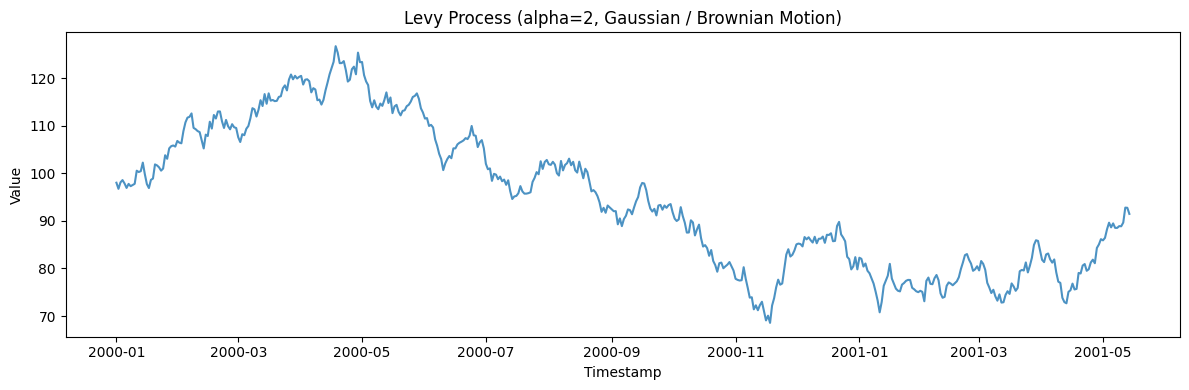

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(gauss_df["ds"].to_list(), gauss_df["y"].to_list(), alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Levy Process (alpha=2, Gaussian / Brownian Motion)")
plt.tight_layout()
plt.show()

## 2. Heavy-tailed process (alpha=1.5)

With alpha < 2, the process has infinite variance and exhibits occasional large jumps.

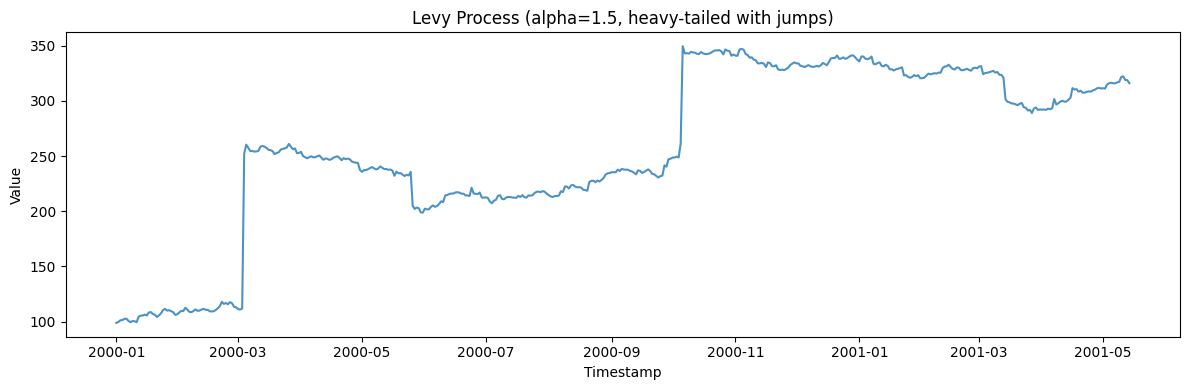

In [ ]:
heavy_gen = LevyProcessGenerator(engine="polars", 
    min_length=500,
    max_length=500,
    freq="D",
    alpha=1.5,
    cumulative=True,
    initial_value=100.0,
    seed=42,
)
heavy_df = heavy_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(heavy_df["ds"].to_list(), heavy_df["y"].to_list(), alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Levy Process (alpha=1.5, heavy-tailed with jumps)")
plt.tight_layout()
plt.show()

## 3. Comparing different alpha values

Lower alpha = heavier tails = more extreme jumps.

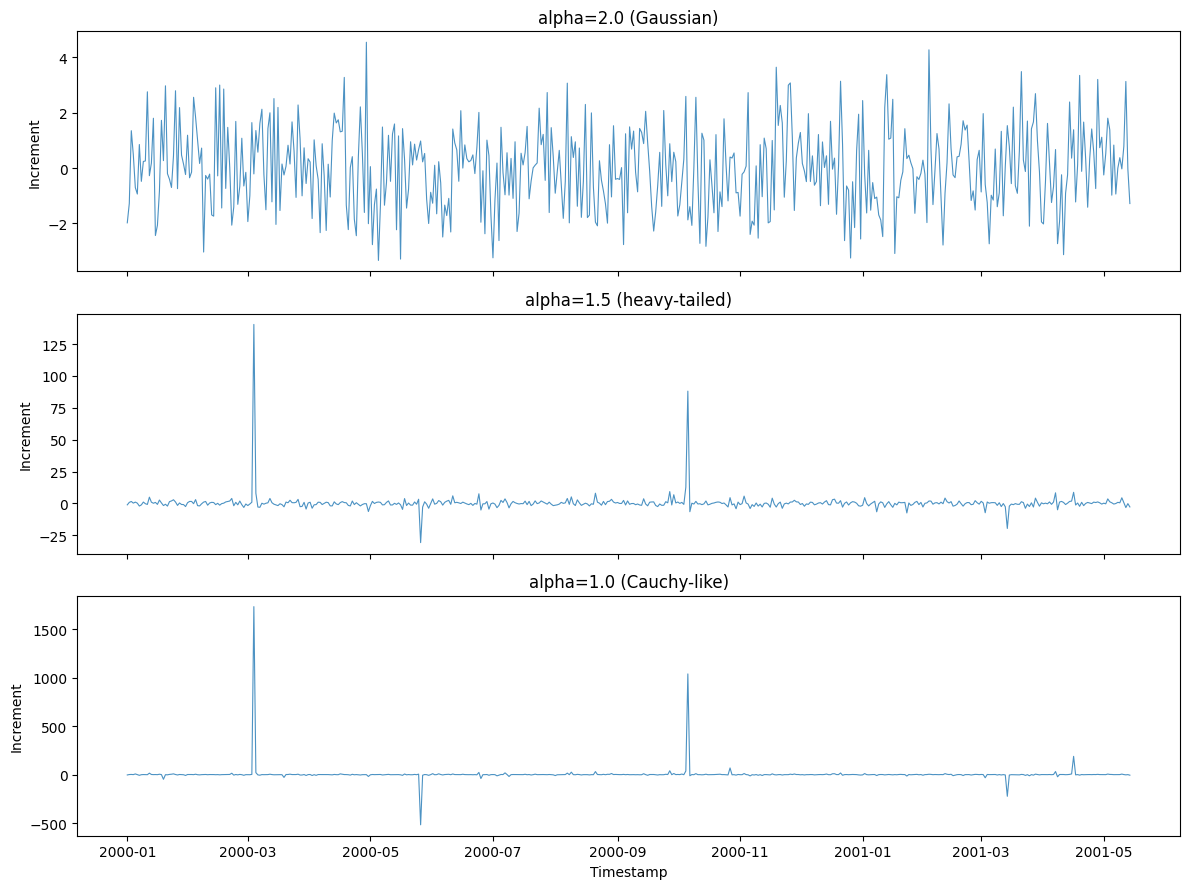

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, alpha, label in zip(
    axes,
    [2.0, 1.5, 1.0],
    ["alpha=2.0 (Gaussian)", "alpha=1.5 (heavy-tailed)", "alpha=1.0 (Cauchy-like)"],
):
    gen = LevyProcessGenerator(engine="polars", 
        min_length=500, max_length=500, freq="D",
        alpha=alpha, cumulative=False, seed=42,
    )
    df = gen.generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), alpha=0.8, linewidth=0.8)
    ax.set_ylabel("Increment")
    ax.set_title(label)

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 4. Multiple series

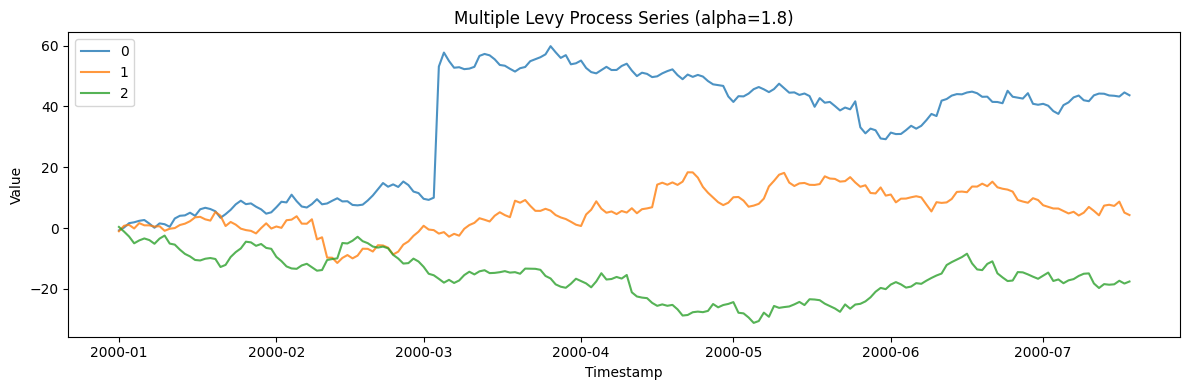

In [ ]:
multi_gen = LevyProcessGenerator(engine="polars", 
    min_length=200, max_length=200, freq="D",
    alpha=1.8, cumulative=True, seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Levy Process Series (alpha=1.8)")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Jump diffusion](jump_diffusion) — a smooth diffusion with separate discrete jumps.
- [GARCH](garch) — heavy-tailed *conditional* behavior via volatility clustering.

The stability parameter is documented in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::